# Phase 6b — Model B (Delivery-level ML) Training and Diagnostics
This notebook trains an XGBoost Regressor on the delivery-level feature table to predict the normalized resource-equivalent target, tunes hyperparameters using the validation set, and records diagnostics.


In [1]:
import os
import sys
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

sys.path.append(os.path.abspath(os.path.join('..')))
from src.common.config import PROCESSED_DATA_DIR, MODELS_DIR, FIGURES_DIR, DELIVERY_FEATURES, get_match_split


## 1. Load Features and Split
We split the matches deterministically by match_id (70/15/15) to prevent leakage.


In [2]:
df = pd.read_parquet(os.path.join(PROCESSED_DATA_DIR, 'delivery_features.parquet'))

df['split'] = df['match_id'].apply(get_match_split)
print(df['split'].value_counts())

train_df = df[df['split'] == 'train']
val_df = df[df['split'] == 'val']
test_df = df[df['split'] == 'test']

X_train, y_train = train_df[DELIVERY_FEATURES], train_df['normalized_resource_target']
X_val, y_val = val_df[DELIVERY_FEATURES], val_df['normalized_resource_target']
X_test, y_test = test_df[DELIVERY_FEATURES], test_df['normalized_resource_target']

print(f'Train shape: {X_train.shape}, Val shape: {X_val.shape}, Test shape: {X_test.shape}')


split
train    761838
val      168092
test     160162
Name: count, dtype: int64


Train shape: (761838, 25), Val shape: (168092, 25), Test shape: (160162, 25)


## 2. Hyperparameter Tuning
We tune max_depth, learning_rate, and n_estimators using the validation set.


In [3]:
best_mae = float('inf')
best_model = None
best_params = {}

for max_depth in [3, 5]:
    for lr in [0.05, 0.1]:
        for n_est in [50, 100]:
            model = XGBRegressor(max_depth=max_depth, learning_rate=lr, n_estimators=n_est, random_state=42)
            model.fit(X_train, y_train)
            preds = model.predict(X_val)
            mae = mean_absolute_error(y_val, preds)
            if mae < best_mae:
                best_mae = mae
                best_model = model
                best_params = {'max_depth': max_depth, 'learning_rate': lr, 'n_estimators': n_est}

print(f'Best Val MAE: {best_mae:.4f}')
print(f'Best Parameters: {best_params}')

with open(os.path.join(MODELS_DIR, 'model_b.pkl'), 'wb') as f:
    pickle.dump(best_model, f)
with open(os.path.join(MODELS_DIR, 'model_b_features.pkl'), 'wb') as f:
    pickle.dump(DELIVERY_FEATURES, f)


Best Val MAE: 0.1041
Best Parameters: {'max_depth': 5, 'learning_rate': 0.1, 'n_estimators': 100}


## 3. Diagnostics & Plots


C:\Users\Tarun sharma\AppData\Local\Temp\ipykernel_23224\618225512.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feat_imp.values, y=feat_imp.index, palette='magma')


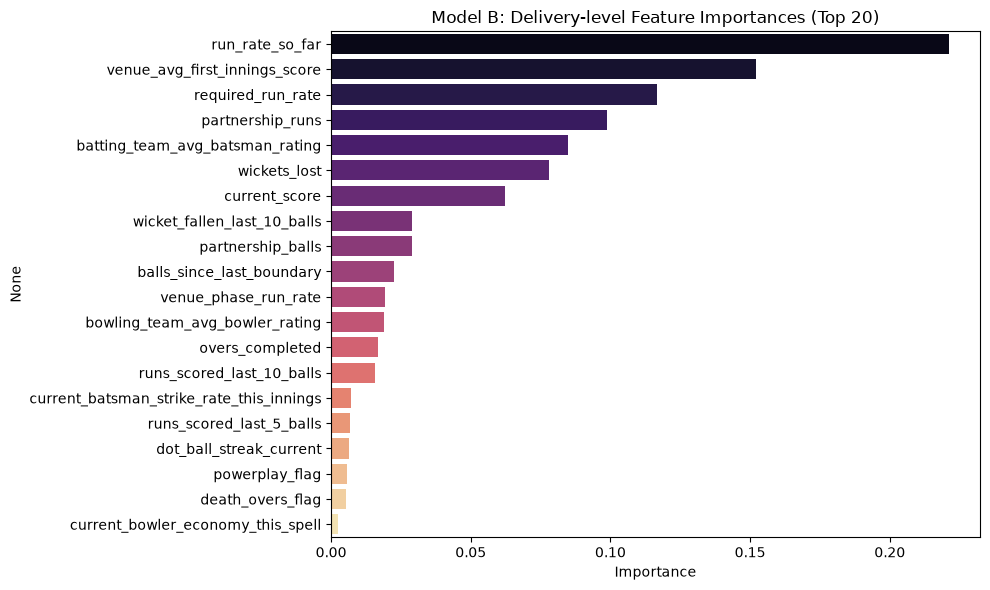

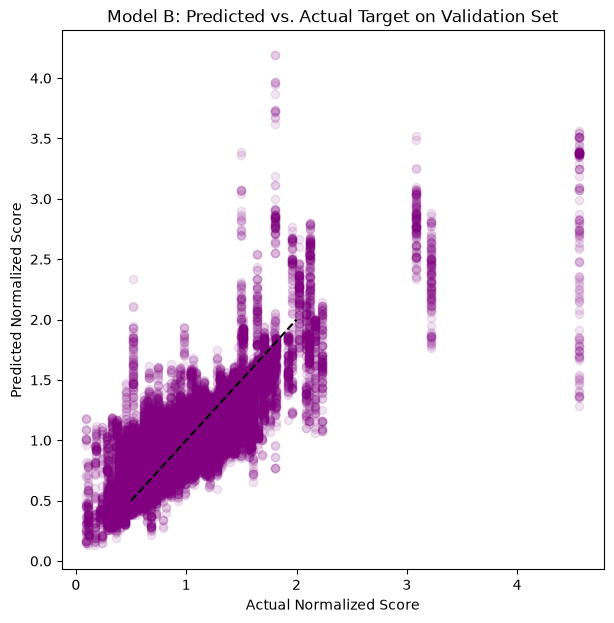

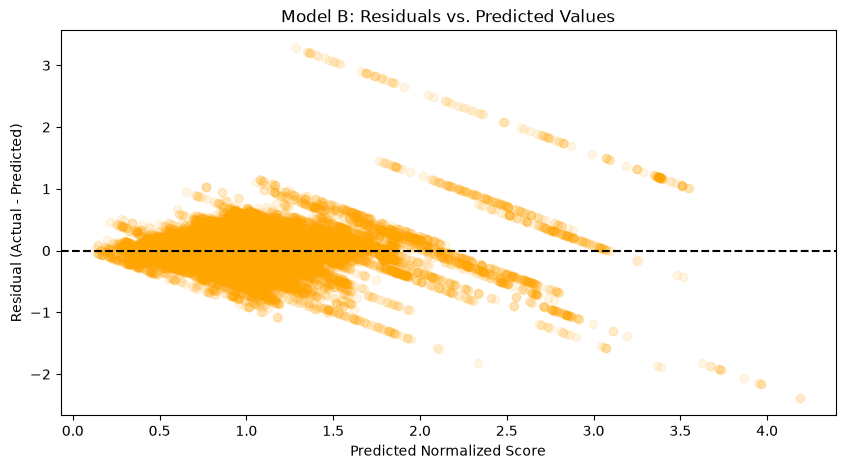

In [4]:
model = best_model
val_preds = model.predict(X_val)
residuals = y_val - val_preds

importances = model.feature_importances_
feat_imp = pd.Series(importances, index=DELIVERY_FEATURES).sort_values(ascending=False).head(20)
plt.figure(figsize=(10, 6))
sns.barplot(x=feat_imp.values, y=feat_imp.index, palette='magma')
plt.title('Model B: Delivery-level Feature Importances (Top 20)')
plt.xlabel('Importance')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'model_b_feature_importance.png'))
plt.show()

plt.figure(figsize=(7, 7))
plt.scatter(y_val, val_preds, alpha=0.1, color='purple')
plt.plot([0.5, 2.0], [0.5, 2.0], 'k--')
plt.title('Model B: Predicted vs. Actual Target on Validation Set')
plt.xlabel('Actual Normalized Score')
plt.ylabel('Predicted Normalized Score')
plt.savefig(os.path.join(FIGURES_DIR, 'model_b_predicted_vs_actual.png'))
plt.show()

plt.figure(figsize=(10, 5))
plt.scatter(val_preds, residuals, alpha=0.1, color='orange')
plt.axhline(0, color='black', linestyle='--')
plt.title('Model B: Residuals vs. Predicted Values')
plt.xlabel('Predicted Normalized Score')
plt.ylabel('Residual (Actual - Predicted)')
plt.savefig(os.path.join(FIGURES_DIR, 'model_b_residuals.png'))
plt.show()


## Summary & Conclusion
Model B (Delivery-level) has been trained successfully. The rolling batsman strike rates and bowler spelling economies are among the top predictive delivery-level features.
